In [1]:
import seaborn as sns
import pandas as pd
import json
import os
import re
sns.set_style('darkgrid')

In [2]:
# model_dir = '/home/luca/Workspace/eye_gaze_injection/models/eye_gaze_finetuning/roberta-base_pp21_50epochs'
models_src_dir = '/home/luca/Workspace/eye_gaze_injection/models/eye_gaze_finetuning/'#roberta-base_pp21_50epochs_lr1e-05'
trainer_state_path = os.path.join(models_src_dir, 'trainer_state.json')

In [3]:
def parse_log_history_loss(log_history):
    logs_dict = {'epoch': [], 'data':[], 'loss':[]}
    for el in log_history:
        if 'loss' in el:
            logs_dict['epoch'].append(el['epoch'])
            logs_dict['data'].append('train')
            logs_dict['loss'].append(el['loss'])
        else:
            if 'eval_loss' in el:
                logs_dict['epoch'].append(el['epoch'])
                logs_dict['data'].append('eval')
                logs_dict['loss'].append(el['eval_loss'])
    return pd.DataFrame.from_dict(logs_dict)

In [4]:
lr = '5e-05'

In [5]:
all_dfs = []
for model_name in os.listdir(models_src_dir):
    if model_name.endswith(f'_lr{lr}'):
        user_id =  re.findall(r'pp(\d*)_', model_name)[0]
        trainer_state_path = os.path.join(models_src_dir, model_name, 'trainer_state.json')
        with open(trainer_state_path, 'r') as src_file:
            trainer_state = json.load(src_file)
        log_history_df = parse_log_history_loss(trainer_state['log_history'])
        log_history_df['user'] = user_id
        all_dfs.append(log_history_df)
all_dfs = pd.concat(all_dfs, axis=0)

<Axes: xlabel='epoch', ylabel='loss'>

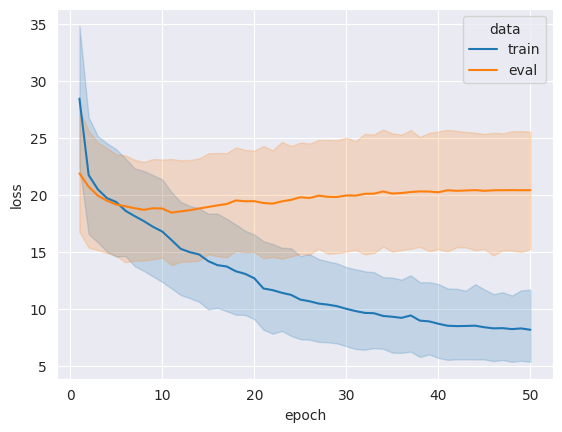

In [6]:
sns.lineplot(data=all_dfs, x='epoch', y='loss', hue='data')

In [7]:
def parse_log_history_eval_metrics(log_history):
    logs_dict = {'epoch': [], 'metric':[], 'score':[], 'label':[]}
    for el in log_history:
        if 'eval_loss' in el:
            epoch = el['epoch']
            for k, v in el.items():
                if k.startswith('eval_label_'):
                    label = k[len('eval_label_'):]
                    for metric, score in v.items():
                        logs_dict['epoch'].append(epoch)
                        logs_dict['label'].append(label)
                        logs_dict['metric'].append(metric)
                        logs_dict['score'].append(score)
    return pd.DataFrame.from_dict(logs_dict)

In [8]:
all_dfs = []
for model_name in os.listdir(models_src_dir):
    if model_name.endswith(f'_lr{lr}'):
        user_id =  re.findall(r'pp(\d*)_', model_name)[0]
        trainer_state_path = os.path.join(models_src_dir, model_name, 'trainer_state.json')
        with open(trainer_state_path, 'r') as src_file:
            trainer_state = json.load(src_file)
        eval_metrics_df = parse_log_history_eval_metrics(trainer_state['log_history'])
        eval_metrics_df['user'] = user_id
        all_dfs.append(eval_metrics_df)
all_dfs = pd.concat(all_dfs, axis=0)

In [9]:
eval_metrics_df = parse_log_history_eval_metrics(trainer_state['log_history'])

In [10]:
eval_metrics_df

,epoch,metric,score,label
0,1.0,mae,5.455668,dur
1,1.0,spearmanr,0.201707,dur
2,1.0,mae,5.459594,firstfix_dur
3,1.0,spearmanr,0.005375,firstfix_dur
4,1.0,mae,5.447133,firstrun_dur
...,...,...,...,...
495,50.0,spearmanr,0.383952,firstrun_dur
496,50.0,mae,4.684376,firstrun_nfix
497,50.0,spearmanr,0.385753,firstrun_nfix
498,50.0,mae,4.680096,nfix


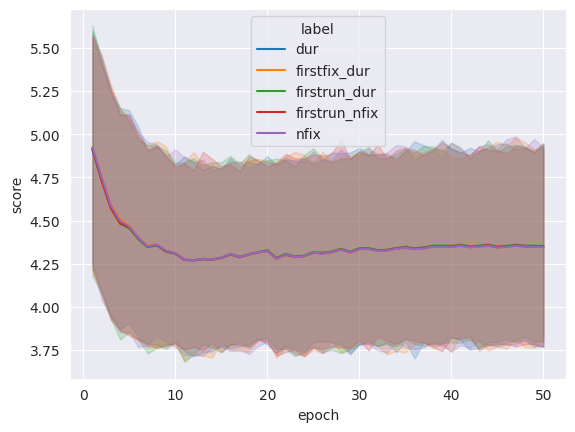

In [11]:
sns.lineplot(data=all_dfs[all_dfs['metric'] == 'mae'], x='epoch', y='score', hue='label');

<Axes: xlabel='epoch', ylabel='score'>

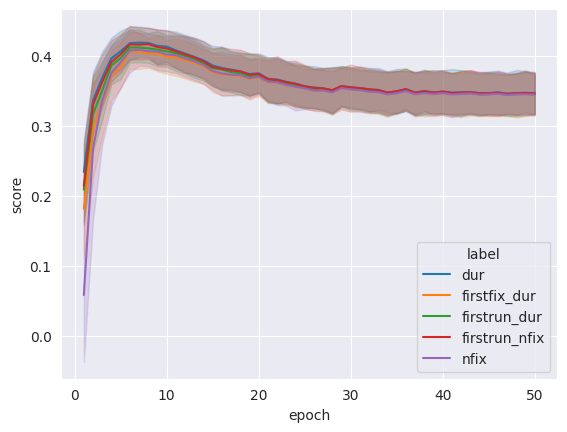

In [12]:
sns.lineplot(data=all_dfs[all_dfs['metric'] == 'spearmanr'], x='epoch', y='score', hue='label')